# Task 3 — The Vanishing Gradient Problem

### Introduction & Intuitive Explanation
Why do standard RNNs struggle to learn long-range memory? The root cause is the **Vanishing Gradient Problem**.

#### The Telephone Game Analogy
Imagine a game of telephone with 100 people. The first person whispers a sentence, and each subsequent person whispers what they heard to the next. By the time it reaches the 100th person, the original message is completely lost. 

Similarly, during backpropagation, error gradients are "whispered" backward through time to update the network weights. If we multiply these gradients by numbers slightly less than 1.0 at each step, after 100 time steps, the gradient becomes virtually zero ($10^{-15}$). The early layers of the sequence receive no update signal, so the model "forgets" the beginning of the sentence.

#### The Mathematical Root Cause
Under the hood, BPTT calculates the gradient of the loss $L$ at step $T$ with respect to the hidden state $h_t$ at step $t$:
$$\frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial h_T} \frac{\partial h_T}{\partial h_t}$$

The transition gradient involves a chain of matrix multiplications:
$$\frac{\partial h_T}{\partial h_t} = \prod_{k=t+1}^{T} \text{diag}(1 - h_k^2) W_{hh}^T$$

- **The Derivative of Tanh**: The derivative of $\tanh(x)$ is $1 - \tanh^2(x)$, which is always between $[0, 1]$.
- **Eigenvalue Decay**: The gradient is multiplied by the hidden-to-hidden weight matrix $W_{hh}$ exactly $T-t$ times.
  - If the largest eigenvalue of $W_{hh}$ is **less than 1**, the gradient norm will **vanish exponentially** (shrink to zero), preventing the network from learning long-term dependencies.
  - If the largest eigenvalue is **greater than 1**, the gradient norm can **explode exponentially** (grow to infinity, leading to `NaN` values), causing training to crash.

This task demonstrates this issue empirically by building a simple RNN, executing a backward pass, and plotting the gradient norms at each time step $t$ across sequence lengths of 5, 25, and 100.

### Core Use Cases
- **Debugging Convergence**: Identifying why models fail to learn relationships over long sentences.
- **Architecture Validation**: Motivating the transition from Vanilla RNNs to Gated Models (LSTMs, GRUs).



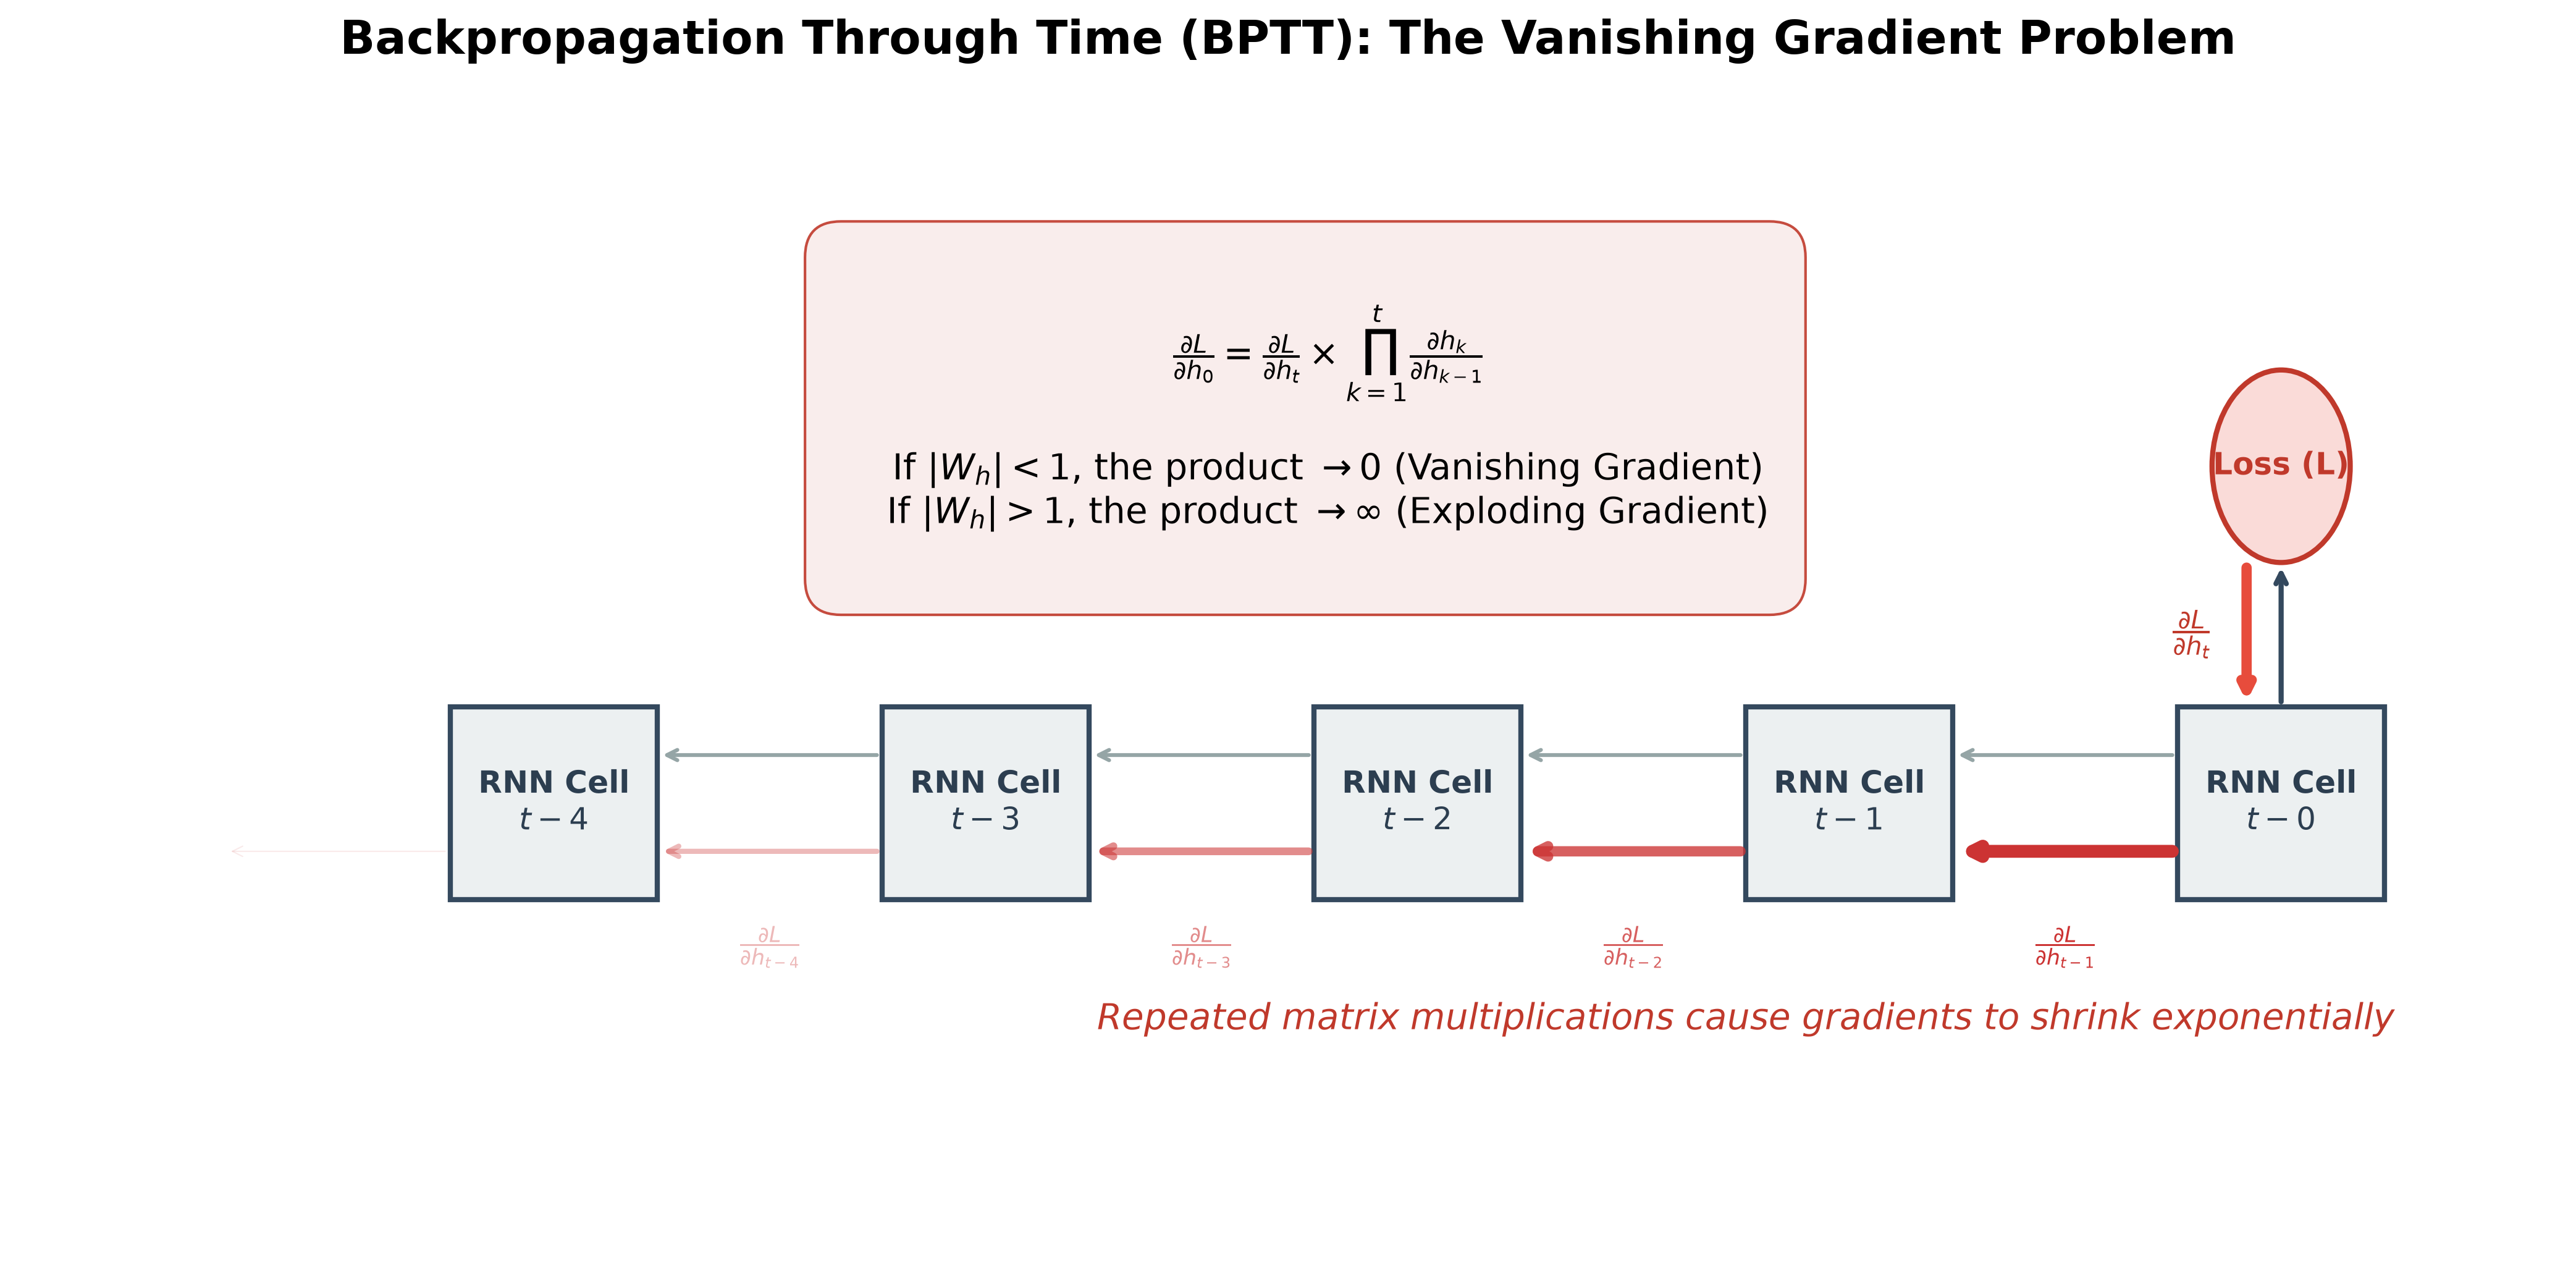

### Step 1 — Track Gradient Norms Over Sequence Length 5, 25, and 100


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed
torch.manual_seed(42)

class SimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True, num_layers=1)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        out, h = self.rnn(x)
        return out, h

def run_gradient_experiment(seq_len):
    input_dim = 10
    hidden_dim = 20
    
    model = SimpleRNN(input_dim, hidden_dim)
    x = torch.randn(1, seq_len, input_dim)
    
    h_states = []
    h_prev = torch.zeros(1, hidden_dim, requires_grad=True)
    
    W_ih = model.rnn.weight_ih_l0
    W_hh = model.rnn.weight_hh_l0
    b_ih = model.rnn.bias_ih_l0
    b_hh = model.rnn.bias_hh_l0
    
    for t in range(seq_len):
        x_t = x[0, t:t+1]
        h_t = torch.tanh(
            torch.matmul(x_t, W_ih.t()) + b_ih + 
            torch.matmul(h_prev, W_hh.t()) + b_hh
        )
        h_t.retain_grad()
        h_states.append(h_t)
        h_prev = h_t
        
    loss = torch.sum(h_states[-1] ** 2)
    loss.backward()
    
    grad_norms = []
    for t in range(seq_len):
        grad = h_states[t].grad
        if grad is not None:
            norm = torch.norm(grad).item()
            grad_norms.append(norm)
        else:
            grad_norms.append(0.0)
            
    return grad_norms

norms_5 = run_gradient_experiment(5)
norms_25 = run_gradient_experiment(25)
norms_100 = run_gradient_experiment(100)

print("Gradient Norm at Step 1 (t=1) vs Last Step (t=T):")
print(f"  Length 5   -> t=1: {norms_5[0]:.6f} | t=5: {norms_5[-1]:.6f}")
print(f"  Length 25  -> t=1: {norms_25[0]:.6e} | t=25: {norms_25[-1]:.6f}")
print(f"  Length 100 -> t=1: {norms_100[0]:.6e} | t=100: {norms_100[-1]:.6f}")



Gradient Norm at Step 1 (t=1) vs Last Step (t=T):
  Length 5   -> t=1: 0.155039 | t=5: 3.814129
  Length 25  -> t=1: 8.333727e-06 | t=25: 3.218602
  Length 100 -> t=1: 0.000000e+00 | t=100: 2.950819


### Step 2 — Visualize Gradient Decay Heatmaps/Curves


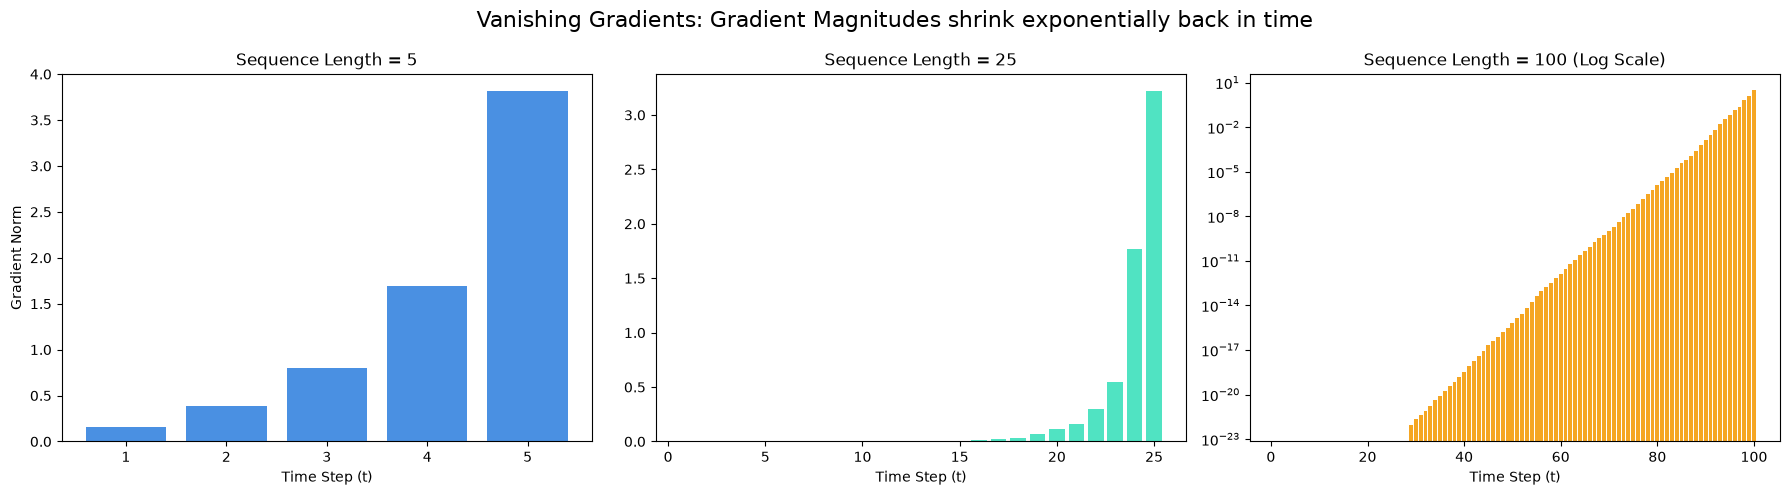

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 5
axes[0].bar(range(1, 6), norms_5, color='#4A90E2')
axes[0].set_title("Sequence Length = 5")
axes[0].set_xlabel("Time Step (t)")
axes[0].set_ylabel("Gradient Norm")

# Plot 25
axes[1].bar(range(1, 26), norms_25, color='#50E3C2')
axes[1].set_title("Sequence Length = 25")
axes[1].set_xlabel("Time Step (t)")

# Plot 100 (Log scale to view tiny values)
axes[2].bar(range(1, 101), norms_100, color='#F5A623')
axes[2].set_title("Sequence Length = 100 (Log Scale)")
axes[2].set_yscale('log')
axes[2].set_xlabel("Time Step (t)")

plt.suptitle("Vanishing Gradients: Gradient Magnitudes shrink exponentially back in time", fontsize=16)
plt.tight_layout()
plt.savefig("outputs/vanishing_gradients.png")
plt.show()



### Step 3 — User-Defined Interactive Evaluation Function
Enter custom sequence lengths below to run the BPTT gradient analysis and plot the decay curve dynamically.


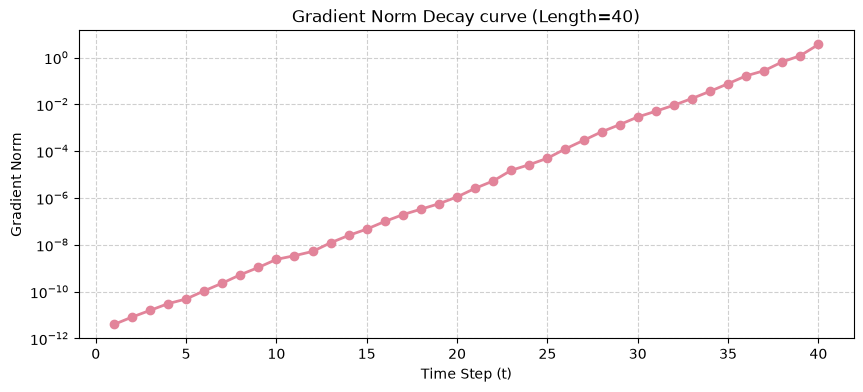

Ratio of Early/Final Gradient (t=1 / t=40): 1.0944e-12
If this ratio is extremely small (e.g. < 1e-5), the model has effectively forgotten early inputs.


In [3]:
def evaluate_vanishing_gradients(seq_length):
    """
    User-defined evaluation function. Calculates and plots gradients for any custom sequence length.
    """
    if seq_length < 2 or seq_length > 150:
        print("Please enter a length between 2 and 150.")
        return
        
    grads = run_gradient_experiment(seq_length)
    
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, seq_length + 1), grads, marker='o', color='#E2849A', linewidth=2)
    plt.title(f"Gradient Norm Decay curve (Length={seq_length})")
    plt.xlabel("Time Step (t)")
    plt.ylabel("Gradient Norm")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.yscale('log')
    plt.show()
    
    ratio = grads[0] / grads[-1]
    print(f"Ratio of Early/Final Gradient (t=1 / t={seq_length}): {ratio:.4e}")
    print("If this ratio is extremely small (e.g. < 1e-5), the model has effectively forgotten early inputs.")

# Evaluate with sequence length 40
evaluate_vanishing_gradients(40)

